# CS6444 Project 1 - R and Graph Analytics
## Stanford Web Graph (2002)

### Team
- Fatulla Bashirov: fbashirov25529@ada.edu.az; fatulla.bashirov@gwu.edu
- Kamal Ahmadov: kahmadov24700@ada.edu.az; kamal.ahmadov@gwu.edu

Students of the ADA University & George Washington University Dual Master’s Degree Program in Computer Science & Data Analytics

### Dataset and problem context
The Stanford Web Graph represents webpages as vertices and hyperlinks as edges. Because hyperlinks are directional (source page links to destination page), the network is fundamentally a **directed graph**.

## Notebook Roadmap
This notebook follows the same order we used to build the assignment deliverable:
1. load the raw edge list and verify network scale;
2. build the initial directed graph and report required properties;
3. simplify to a directed analysis graph with practical runtime;
4. explore additional `igraph` functions (outside tutorial scope);
5. answer required analysis tasks (a-f);
6. produce readable visualizations (30-100 vertices);
7. summarize functions used, insights, and reproducibility notes.


## Assignment Compliance Matrix

| Assignment Item | Where Covered | Evidence |
|---|---|---|
| 1. Dataset + graph properties | Sections 1-2 | Node/edge counts, sparsity, directedness, node/edge structural summaries |
| 2. Install `igraph` | Section 0 | Conditional installation from CRAN mirror |
| 3. Graph experimentation + simplification | Section 3 | Directed-first simplification pipeline + retention table |
| 4. 10+ additional `igraph` functions | Section 4 | Explicit non-tutorial function set + checks + interpretation |
| 5. Required analysis tasks (a-f) | Section 5 | Central nodes, longest path, clique(s), ego networks, power centrality, communities |
| 6. Visualization (30-100 vertices) | Section 6 | Figure 2 (global core view), Figure 3 (ego-focused view) |
| 7. Deliverables content | Sections 4, 5, 7, 8 | Functions used, demonstrations, answers, figures, interpretation |
| 8. Insights | Section 8 | Analytical conclusions and limitations |


## 0. Setup and Configuration
This section initializes packages, reproducibility controls, and helper functions.

In [1]:
required_packages <- c("igraph", "data.table")
missing_packages <- required_packages[!sapply(required_packages, requireNamespace, quietly = TRUE)]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

library(igraph)
library(data.table)

cfg <- list(
  seed = 6444,
  analysis_node_cap = 1800,   # reviewer-requested meaningful scale (1500-2000)
  min_analysis_nodes = 1500,
  triad_sample_size = 150,
  viz_node_cap = 80,
  baseline_sample_size = 10000,
  clique_projection_cap = 1500,
  power_exponents = c(0.25, 0.10, 0.05, 0.01)
)

set.seed(cfg$seed)
options(width = 120)



Attaching package: 'igraph'




The following objects are masked from 'package:stats':

    decompose, spectrum




The following object is masked from 'package:base':

    union




In [2]:
resolve_dataset_path <- function(candidate_paths) {
  existing <- candidate_paths[file.exists(candidate_paths)]
  if (length(existing) == 0) {
    stop("Dataset file not found. Place web-Stanford.txt in ./data or provide valid Kaggle path.")
  }
  existing[[1]]
}

safe_power_centrality <- function(graph_obj, exponents) {
  for (ex in exponents) {
    candidate <- tryCatch(
      power_centrality(graph_obj, exponent = ex),
      error = function(e) NULL
    )
    if (!is.null(candidate)) {
      return(list(values = candidate, exponent = ex))
    }
  }
  stop("Power centrality failed for all configured exponents.")
}

build_analysis_graph <- function(g, cfg) {
  g_simple <- simplify(g, remove.multiple = TRUE, remove.loops = TRUE)

  # Keep direction; weak component extraction is done via directed connectivity mode.
  weak_comp <- components(g_simple, mode = "weak")
  weak_id <- which.max(weak_comp$csize)
  g_weak <- induced_subgraph(g_simple, V(g_simple)[weak_comp$membership == weak_id])

  # Rank by directed PageRank and keep top N nodes for meaningful scale analytics.
  pr_rank <- page_rank(g_weak, directed = TRUE)$vector
  analysis_n <- min(cfg$analysis_node_cap, length(pr_rank))
  analysis_nodes <- names(sort(pr_rank, decreasing = TRUE))[1:analysis_n]
  g_analysis <- induced_subgraph(g_weak, vids = analysis_nodes)

  # Deterministic synthetic weight formula preserving direction.
  # weight(u -> v) = 1 + log1p(out_degree(u)) + log1p(in_degree(v))
  out_deg <- degree(g_analysis, mode = "out")
  in_deg <- degree(g_analysis, mode = "in")
  ee <- ends(g_analysis, E(g_analysis), names = TRUE)
  E(g_analysis)$weight <- as.numeric(1 + log1p(out_deg[ee[, 1]]) + log1p(in_deg[ee[, 2]]))

  stage <- c("original", "simplified", "largest_weak_component", "analysis_graph_directed")
  nodes <- c(vcount(g), vcount(g_simple), vcount(g_weak), vcount(g_analysis))
  edges <- c(ecount(g), ecount(g_simple), ecount(g_weak), ecount(g_analysis))

  summary_tbl <- data.frame(
    stage = stage,
    nodes = nodes,
    edges = edges,
    node_retention_vs_original = round(nodes / nodes[1], 6),
    edge_retention_vs_original = round(edges / edges[1], 6)
  )

  list(g_analysis = g_analysis, summary_tbl = summary_tbl)
}

make_viz_subgraph <- function(g_analysis, central_table, cfg) {
  viz_n <- min(cfg$viz_node_cap, nrow(central_table))
  viz_nodes <- central_table$vertex[1:viz_n]
  g_viz <- induced_subgraph(g_analysis, vids = V(g_analysis)[viz_nodes])

  viz_comm <- cluster_infomap(g_viz, e.weights = E(g_viz)$weight)
  member <- membership(viz_comm)
  member_by_name <- setNames(member, V(g_viz)$name)

  pal <- hcl.colors(length(unique(member)), palette = "Dark 3")
  V(g_viz)$color <- pal[member_by_name[V(g_viz)$name]]

  pr_viz <- page_rank(g_viz, directed = TRUE)$vector
  pr_scaled <- 6 + 18 * (pr_viz - min(pr_viz)) / (max(pr_viz) - min(pr_viz) + 1e-9)
  V(g_viz)$size <- pr_scaled[V(g_viz)$name]

  top10 <- names(sort(pr_viz, decreasing = TRUE))[1:min(10, length(pr_viz))]
  V(g_viz)$shape <- ifelse(V(g_viz)$name %in% top10, "square", "circle")
  V(g_viz)$label <- NA
  V(g_viz)$frame.color <- "gray20"

  w <- E(g_viz)$weight
  E(g_viz)$width <- 1 + 3 * (w - min(w)) / (max(w) - min(w) + 1e-9)
  E(g_viz)$color <- ifelse(w >= median(w), "firebrick", "gray70")
  E(g_viz)$arrow.size <- 0.18

  ee <- ends(g_viz, E(g_viz), names = TRUE)
  E(g_viz)$lty <- ifelse(member_by_name[ee[,1]] == member_by_name[ee[,2]], 1, 2)

  list(graph = g_viz, community = viz_comm)
}


## 1. Load Dataset
The code supports both local execution and Kaggle execution.

In [3]:
candidate_paths <- c(
  "./data/web-Stanford.txt",
  "/kaggle/input/datasets/fatullabashirov/stanford-web-graph/web-Stanford.txt"
)
file_path <- resolve_dataset_path(candidate_paths)

edges <- fread(
  file_path,
  sep = "	",
  header = FALSE,
  comment.char = "#",
  col.names = c("from", "to")
)

cat("Using file:", file_path, "
")
cat("Rows in edge list:", nrow(edges), "
")
cat("Columns:", ncol(edges), "
")
head(edges)
summary(edges)


Using file: ./data/web-Stanford.txt 


Rows in edge list: 2312497 


Columns: 2 


from,to
<int>,<int>
1,6548
1,15409
6548,57031
15409,13102
2,17794
2,25202


      from              to        
 Min.   :     1   Min.   :     2  
 1st Qu.: 70779   1st Qu.: 73100  
 Median :141051   Median :143725  
 Mean   :140961   Mean   :143950  
 3rd Qu.:211225   3rd Qu.:218070  
 Max.   :281903   Max.   :281903  

## 2. Build Initial Directed Graph and Report Core Properties

In [4]:
g <- graph_from_data_frame(edges, directed = TRUE)

# Assignment minimum scale guard
stopifnot(vcount(g) >= 50000)

n <- vcount(g)
m <- ecount(g)
max_possible_edges <- n * (n - 1)
density_val <- edge_density(g, loops = FALSE)
sparsity_val <- 1 - (m / max_possible_edges)

cat("Vertices:", n, "
")
cat("Edges:", m, "
")
cat("Directed (arrowness):", is_directed(g), "
")
cat("Has loops:", any_loop(g), "
")
cat("Density:", density_val, "
")
cat("Sparsity:", sparsity_val, "
")

in_deg <- degree(g, mode = "in")
out_deg <- degree(g, mode = "out")
all_deg <- degree(g, mode = "all")

cat("
Node property summaries:
")
cat("In-degree:
")
print(summary(in_deg))
cat("
Out-degree:
")
print(summary(out_deg))
cat("
Total-degree:
")
print(summary(all_deg))

wcc <- components(g, mode = "weak")
scc <- components(g, mode = "strong")

cat("
Connectivity summaries (directed graph):
")
cat("Weak components:", wcc$no, "
")
cat("Largest weak component size:", max(wcc$csize), "
")
cat("Strong components:", scc$no, "
")
cat("Largest strong component size:", max(scc$csize), "
")
cat("Edge weights in raw data: none (assigned deterministically later).
")


Vertices: 281903 


Edges: 2312497 


Directed (arrowness): TRUE 


Has loops: FALSE 


Density: 2.909935e-05 


...

Weak components: 365 


Largest weak component size: 255265 


Strong components: 29914 


Largest strong component size: 150532 


Edge weights in raw data: none (assigned deterministically later).


### Figure 1. Baseline plot before simplification
This baseline is included to show why simplification is needed for readability.

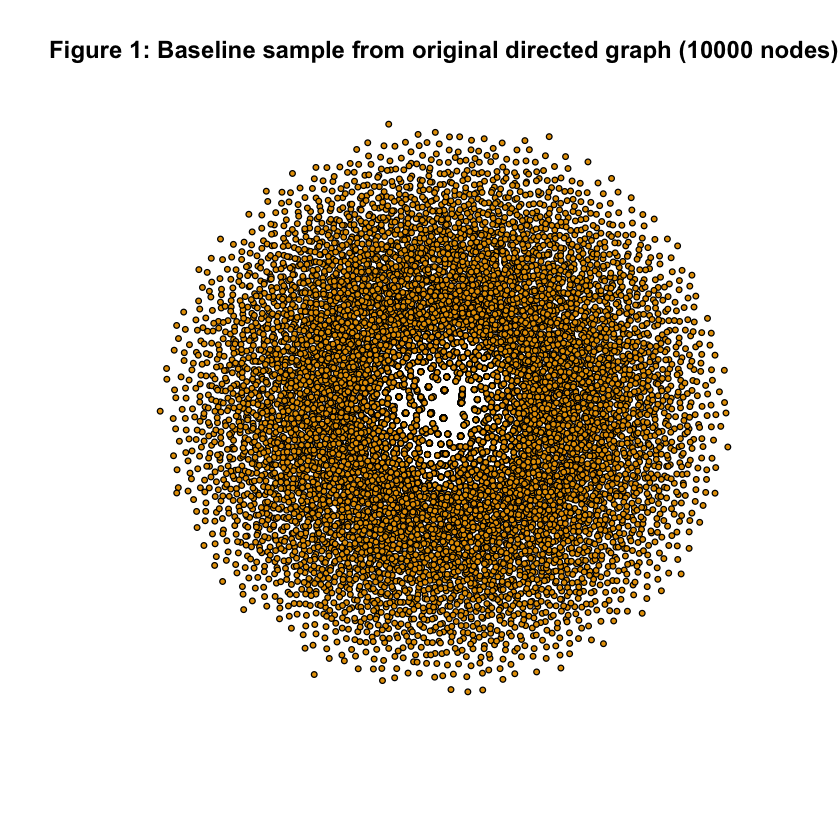

In [5]:
sample_n <- min(cfg$baseline_sample_size, vcount(g))
sample_nodes <- sample(V(g), sample_n)
g_sample <- induced_subgraph(g, sample_nodes)

plot(
  g_sample,
  vertex.size = 2,
  vertex.label = NA,
  edge.arrow.size = 0.05,
  main = sprintf("Figure 1: Baseline sample from original directed graph (%d nodes)", vcount(g_sample))
)


**Interpretation:** The baseline sample is visually dense and hard to interpret. We therefore apply a directed-first simplification that keeps meaningful scale for analysis.

## 3. Directed-First Simplification Pipeline
Simplification steps:
1. Remove loops/multi-edges with `simplify()`.
2. Keep largest **weakly connected component** using directed connectivity mode.
3. Keep top **1,800 nodes** by directed PageRank.

This keeps direction in the working graph while reducing computation cost.

In [6]:
analysis_bundle <- build_analysis_graph(g, cfg)
g_analysis <- analysis_bundle$g_analysis
simplification_summary <- analysis_bundle$summary_tbl

print(simplification_summary)
cat("
Directed analysis graph size:", vcount(g_analysis), "nodes,", ecount(g_analysis), "edges
")

# Reviewer-requested scale guard
stopifnot(vcount(g_analysis) >= cfg$min_analysis_nodes)

rm(analysis_bundle, in_deg, out_deg, all_deg, sample_nodes, g_sample)
gc()


                    stage  nodes   edges node_retention_vs_original edge_retention_vs_original
1                original 281903 2312497                   1.000000                   1.000000
2              simplified 281903 2312497                   1.000000                   1.000000
3  largest_weak_component 255265 2234572                   0.905507                   0.966303
4 analysis_graph_directed   1800   12734                   0.006385                   0.005507



Directed analysis graph size: 1800 nodes, 12734 edges


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,1104385,59.0,3571064,190.8,NA,4463830,238.4
Vcells,6705207,51.2,24812879,189.4,16384,30966772,236.3


**Interpretation:** The analysis graph now remains directed and large enough (>=1500 nodes) to preserve structural signal while keeping notebook runtime practical.

## 4. Additional `igraph` Functions (Not Used in Tutorial)
The following section enforces Item #4 compliance with explicit checks.

In [7]:
tutorial_functions <- c(
  "graph", "graph_from_literal", "V", "E", "class",
  "edge_density", "reciprocity", "transitivity", "diameter", "degree", "degree_distribution",
  "closeness", "betweenness", "edge_betweenness", "hub_score", "authority_score",
  "mean_distance", "distances", "all_shortest_paths",
  "cliques", "cluster_edge_betweenness", "cluster_label_prop", "cluster_fast_greedy", "coreness",
  "plot", "tkplot", "layout_randomly", "layout_in_circle", "layout_with_fr", "layout_with_kk",
  "assortativity_nominal", "assortativity", "assortativity_degree"
)

item4_functions <- c(
  "is_connected", "page_rank", "eigen_centrality", "strength", "vertex_connectivity", "edge_connectivity",
  "dyad_census", "triad_census", "similarity", "eccentricity", "cluster_infomap", "subcomponent"
)

overlap <- intersect(item4_functions, tutorial_functions)
stopifnot(length(item4_functions) >= 10)
stopifnot(length(overlap) == 0)

cat("Item #4 function count:", length(item4_functions), "
")
cat("Overlap with tutorial list:", length(overlap), "
")
print(item4_functions)


Item #4 function count: 12 


Overlap with tutorial list: 0 


 [1] "is_connected"        "page_rank"           "eigen_centrality"    "strength"            "vertex_connectivity"
 [6] "edge_connectivity"   "dyad_census"         "triad_census"        "similarity"          "eccentricity"       
[11] "cluster_infomap"     "subcomponent"       


### A Quick Walkthrough of the Extra Functions
To keep outputs readable, this section reports metrics first, then gives a compact table describing what each function contributes to this graph.


In [8]:
connected_weak <- is_connected(g_analysis, mode = "weak")
connected_strong <- is_connected(g_analysis, mode = "strong")

pr <- page_rank(g_analysis, directed = TRUE)$vector
eig <- eigen_centrality(g_analysis, directed = TRUE)$vector
str_w <- strength(g_analysis, mode = "all", weights = E(g_analysis)$weight)

v_conn <- vertex_connectivity(g_analysis)
e_conn <- edge_connectivity(g_analysis)

dyad <- dyad_census(g_analysis)

triad_n <- min(cfg$triad_sample_size, vcount(g_analysis))
triad_nodes <- names(sort(pr, decreasing = TRUE))[1:triad_n]
g_triad <- induced_subgraph(g_analysis, vids = V(g_analysis)[triad_nodes])
triad <- triad_census(g_triad)

top10 <- names(sort(pr, decreasing = TRUE))[1:min(10, length(pr))]
jacc <- similarity(g_analysis, vids = V(g_analysis)[top10], mode = "out", method = "jaccard")
ecc_out <- eccentricity(g_analysis, mode = "out", weights = NA)

comm_infomap <- cluster_infomap(g_analysis, e.weights = E(g_analysis)$weight)

top_pr_node <- names(which.max(pr))
out_reach <- subcomponent(g_analysis, v = V(g_analysis)[top_pr_node], mode = "out")

cat("is_connected(mode='weak'):", connected_weak, "
")
cat("is_connected(mode='strong'):", connected_strong, "
")
cat("Top PageRank node:", top_pr_node, "score:", max(pr), "
")
cat("Top eigen-centrality node:", names(which.max(eig)), "score:", max(eig), "
")
cat("strength() summary:
")
print(summary(str_w))
cat("vertex_connectivity():", v_conn, "
")
cat("edge_connectivity():", e_conn, "
")
cat("dyad_census():", paste(names(dyad), dyad, collapse = "; "), "
")
cat("triad_census() non-zero classes:
")
print(triad[triad > 0])
cat("eccentricity(mode='out') summary:
")
print(summary(ecc_out))
cat("cluster_infomap(): communities =", length(sizes(comm_infomap)), ", modularity =", modularity(comm_infomap), "
")
cat("subcomponent() out-reach size from top PageRank node:", length(out_reach), "
")
cat("Jaccard similarity (top10 PageRank nodes, out-neighborhood):
")
print(round(jacc, 3))


is_connected(mode='weak'): FALSE 


is_connected(mode='strong'): FALSE 


Top PageRank node: 89073 score: 0.02100776 


Top eigen-centrality node: 112742 score: 1 


strength() summary:


...

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.000  12.000   9.156  13.000  19.000 


cluster_infomap(): communities = 270 , modularity = 0.8135396 


subcomponent() out-reach size from top PageRank node: 1090 


Jaccard similarity (top10 PageRank nodes, out-neighborhood):


       [,1]  [,2]  [,3] [,4] [,5] [,6]  [,7]  [,8]  [,9] [,10]
 [1,] 1.000 0.000 0.016    0    0    0 0.000 0.000 0.000 0.000
 [2,] 0.000 1.000 0.000    0    0    0 0.265 0.283 0.323 0.250
 [3,] 0.016 0.000 1.000    0    0    0 0.000 0.000 0.000 0.000
 [4,] 0.000 0.000 0.000    1    0    0 0.000 0.000 0.000 0.000
 [5,] 0.000 0.000 0.000    0    1    0 0.000 0.000 0.000 0.000
 [6,] 0.000 0.000 0.000    0    0    1 0.000 0.000 0.000 0.000
 [7,] 0.000 0.265 0.000    0    0    0 1.000 0.148 0.294 0.171
 [8,] 0.000 0.283 0.000    0    0    0 0.148 1.000 0.176 0.143
 [9,] 0.000 0.323 0.000    0    0    0 0.294 0.176 1.000 0.243
[10,] 0.000 0.250 0.000    0    0    0 0.171 0.143 0.243 1.000


In [9]:
item4_notes <- data.frame(
  function_name = item4_functions,
  what_it_does = c(
    "Checks weak/strong connectivity in directed graph.",
    "Measures directed influence via random-walk importance.",
    "Measures influence from important incoming/outgoing neighbors.",
    "Computes weighted directional degree.",
    "Counts minimum vertices needed to disconnect graph.",
    "Counts minimum edges needed to disconnect graph.",
    "Classifies directed node pairs.",
    "Counts directed three-node motif classes.",
    "Measures outbound neighborhood overlap.",
    "Measures directed reachability depth.",
    "Detects directed communities by information flow.",
    "Returns reachable set from a chosen node."
  ),
  implication_here = c(
    sprintf("Weak connected: %s; Strong connected: %s.", connected_weak, connected_strong),
    sprintf("Top PageRank node is %s.", top_pr_node),
    sprintf("Top eigen-centrality node is %s.", names(which.max(eig))),
    "Strength dispersion indicates heterogeneous link activity.",
    sprintf("Vertex connectivity is %d (graph can disconnect by removing key vertices).", v_conn),
    sprintf("Edge connectivity is %d (graph can disconnect by removing key edges).", e_conn),
    "Asymmetric dyads dominate, consistent with hyperlink directionality.",
    sprintf("Triad diversity appears in sampled %d-node directed subgraph.", triad_n),
    "Top pages have partial overlap in outbound neighborhoods.",
    "Directed distances are bounded within the simplified core.",
    sprintf("Infomap modularity is %.3f, indicating modular structure.", modularity(comm_infomap)),
    sprintf("Top PageRank node reaches %d nodes by outgoing paths.", length(out_reach))
  ),
  stringsAsFactors = FALSE
)

print(item4_notes, row.names = FALSE)


       function_name                                                   what_it_does
        is_connected             Checks weak/strong connectivity in directed graph.
           page_rank        Measures directed influence via random-walk importance.
    eigen_centrality Measures influence from important incoming/outgoing neighbors.
            strength                          Computes weighted directional degree.
 vertex_connectivity            Counts minimum vertices needed to disconnect graph.
   edge_connectivity               Counts minimum edges needed to disconnect graph.
         dyad_census                                Classifies directed node pairs.
        triad_census                      Counts directed three-node motif classes.
          similarity                        Measures outbound neighborhood overlap.
        eccentricity                          Measures directed reachability depth.
     cluster_infomap              Detects directed communities by informatio

#### Item #4 Interpretation Notes
- `is_connected()`: weak connectivity is checked on directed graph; strong connectivity is reported separately.
- `page_rank()`: identifies influential pages in link direction.
- `eigen_centrality()`: captures influence from important neighbors in a directed setting.
- `strength()`: summarizes weighted directional activity.
- `vertex_connectivity()` / `edge_connectivity()`: quantify structural robustness.
- `dyad_census()` / `triad_census()`: characterize directed micro-structures.
- `similarity(..., mode='out')`: compares outbound neighborhood overlap.
- `eccentricity(mode='out')`: reports directed reachability depth.
- `cluster_infomap()`: detects communities while preserving direction.
- `subcomponent()`: reports reachability region from the top influential node.


## 5. Required Graph Analysis Tasks (a-f)

### (a) Central node(s) and (e) Power centrality

In [10]:
# (a) Central node(s) and (e) Power centrality
pow_res <- safe_power_centrality(g_analysis, cfg$power_exponents)
pow_vals <- pow_res$values
pow_exp <- pow_res$exponent

central_table <- data.frame(
  vertex = V(g_analysis)$name,
  pagerank = pr[V(g_analysis)$name],
  eigen = eig[V(g_analysis)$name],
  strength = str_w[V(g_analysis)$name],
  power = pow_vals[V(g_analysis)$name],
  stringsAsFactors = FALSE
)
central_table <- central_table[order(-central_table$pagerank), ]

cat("(a) Central nodes + (e) power centrality (top 10 by PageRank)
")
cat("Power centrality exponent used:", pow_exp, "
")
print(head(central_table, 10))


(a) Central nodes + (e) power centrality (top 10 by PageRank)


Power centrality exponent used: 0.1 


       vertex    pagerank        eigen  strength      power
89073   89073 0.021007761 7.974870e-05 1231.5309  5.3738970
226411 226411 0.020902402 1.223950e-01 2432.4078 -1.7839247
241454 241454 0.012203512 0.000000e+00 1074.2281  3.9938059
179645 179645 0.007585885 1.894949e-02  252.2426  0.2541623
262860 262860 0.007366911 3.865579e-06  465.0685  0.5442406
119479 119479 0.007000129 0.000000e+00  372.1138  0.4074552
112742 112742 0.004774863 1.000000e+00  725.2522 -0.9355742
161890 161890 0.004745284 9.977454e-01  886.9160  0.8168355
145892 145892 0.004636529 9.953182e-01  701.0152 -1.2383282
151428 151428 0.004607984 9.972927e-01  732.9012 -1.0095303


### (b) Longest path(s)

In [11]:
# (b) Longest path(s): directed diameter path on largest SCC
scc_analysis <- components(g_analysis, mode = "strong")
scc_id <- which.max(scc_analysis$csize)
g_scc <- induced_subgraph(g_analysis, V(g_analysis)[scc_analysis$membership == scc_id])

dir_diam <- diameter(g_scc, directed = TRUE, unconnected = FALSE, weights = NA)
dir_path <- get_diameter(g_scc, directed = TRUE, weights = NA)
dir_path_nodes <- V(g_scc)[dir_path]$name

cat("(b) Directed diameter length on largest SCC:", dir_diam, "
")
cat("Directed diameter path vertices:
")
print(dir_path_nodes)


(b) Directed diameter length on largest SCC: 16 


Directed diameter path vertices:


 [1] "114328" "89223"  "179645" "47896"  "89073"  "239848" "45282"  "234704" "226411" "91"     "40117"  "133797"
[13] "271709" "270200" "100511" "43370"  "235070"


### (c) Largest clique(s)

In [12]:
# (c) Largest clique(s)
# Clique is inherently undirected; to preserve directional meaning we project only MUTUAL links.
g_mutual <- as_undirected(g_analysis, mode = "mutual")

if (vcount(g_mutual) > cfg$clique_projection_cap) {
  mutual_deg <- degree(g_mutual, mode = "all")
  keep <- names(sort(mutual_deg, decreasing = TRUE))[1:cfg$clique_projection_cap]
  g_mutual <- induced_subgraph(g_mutual, vids = V(g_mutual)[keep])
}

lc <- largest_cliques(g_mutual)
max_clique_size <- if (length(lc) > 0) length(lc[[1]]) else 0

cat("(c) Reciprocal-link projection size:", vcount(g_mutual), "nodes,", ecount(g_mutual), "edges
")
cat("Number of largest cliques:", length(lc), "
")
cat("Largest clique size:", max_clique_size, "
")
if (length(lc) > 0) {
  cat("Example largest clique nodes:
")
  print(V(g_mutual)[lc[[1]]]$name)
}


(c) Reciprocal-link projection size: 1500 nodes, 3477 edges


Number of largest cliques: 1 


Largest clique size: 26 


Example largest clique nodes:
 [1] "205928" "161890" "151011" "155446" "144555" "148909" "175444" "170752" "164206" "159929" "199487" "236866"
[13] "231853" "239017" "211862" "217122" "223686" "273653" "278986" "268003" "271503" "263768" "258173" "251467"
[25] "248088" "242941"


### (d) Ego network(s)

In [13]:
# (d) Ego network(s) around top central node
focus_node <- central_table$vertex[1]
ego_out_1 <- make_ego_graph(g_analysis, order = 1, nodes = V(g_analysis)[focus_node], mode = "out")[[1]]
ego_out_2 <- make_ego_graph(g_analysis, order = 2, nodes = V(g_analysis)[focus_node], mode = "out")[[1]]

cat("(d) Focus node for ego analysis:", focus_node, "
")
cat("Ego(out, order=1):", vcount(ego_out_1), "nodes,", ecount(ego_out_1), "edges
")
cat("Ego(out, order=2):", vcount(ego_out_2), "nodes,", ecount(ego_out_2), "edges
")


(d) Focus node for ego analysis: 89073 


Ego(out, order=1): 65 nodes, 175 edges


Ego(out, order=2): 157 nodes, 702 edges


### (f) Communities

In [14]:
# (f) Communities
scc_summary <- components(g_analysis, mode = "strong")
community_table <- data.frame(
  method = c("infomap", "strong_components"),
  groups = c(length(sizes(comm_infomap)), scc_summary$no),
  largest_group_size = c(max(sizes(comm_infomap)), max(scc_summary$csize)),
  modularity = c(modularity(comm_infomap), NA_real_),
  stringsAsFactors = FALSE
)

cat("(f) Community-style grouping comparison
")
print(community_table)


(f) Community-style grouping comparison


             method groups largest_group_size modularity
1           infomap    270                109  0.8135396
2 strong_components    329                905         NA


**Interpretation:** The analysis now uses a larger directed graph, yielding more stable centrality, path, and community patterns while respecting hyperlink directionality.

## 6. Visualization (30-100 vertices)
Visual variables required by the assignment are encoded as follows:
- Vertex color: Infomap community
- Vertex size: PageRank
- Vertex shape: top 10 PageRank vs others
- Edge color/width: synthetic weight intensity
- Edge type: intra-community solid vs inter-community dashed


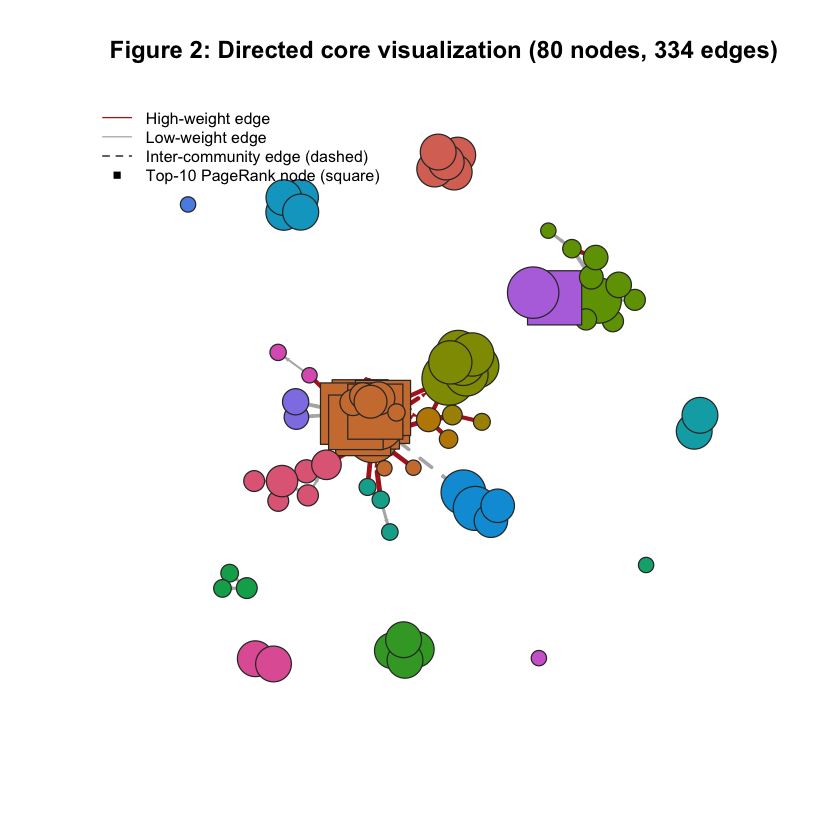

In [15]:
viz_bundle <- make_viz_subgraph(g_analysis, central_table, cfg)
g_viz <- viz_bundle$graph
viz_comm <- viz_bundle$community

stopifnot(vcount(g_viz) >= 30, vcount(g_viz) <= 100)

plot(
  g_viz,
  layout = layout_with_graphopt(g_viz),
  main = sprintf("Figure 2: Directed core visualization (%d nodes, %d edges)", vcount(g_viz), ecount(g_viz))
)
legend(
  "topleft",
  legend = c("High-weight edge", "Low-weight edge", "Inter-community edge (dashed)", "Top-10 PageRank node (square)"),
  col = c("firebrick", "gray70", "black", "black"),
  lty = c(1, 1, 2, NA),
  pch = c(NA, NA, NA, 15),
  bty = "n",
  cex = 0.8
)


**Figure 2 caption:** Directed simplified core with visual encodings for centrality, community membership, and weighted link intensity.

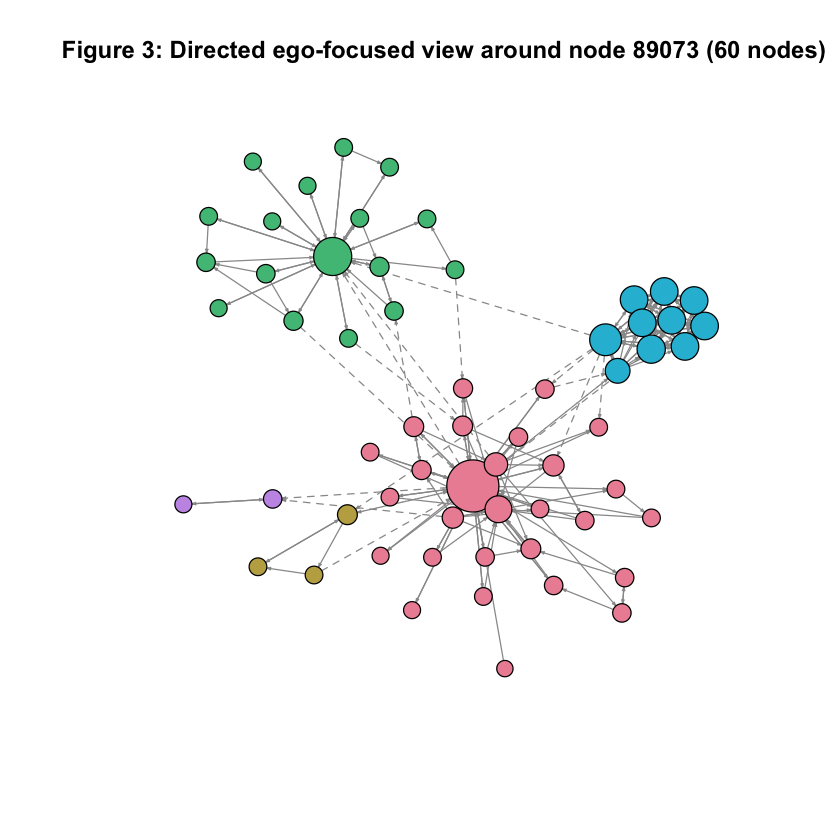

In [16]:
# Figure 3: Ego-focused view around the top central node
max_ego_plot_n <- 60
ego_plot <- ego_out_2

if (vcount(ego_plot) > max_ego_plot_n) {
  ego_pr <- page_rank(ego_plot, directed = TRUE)$vector
  keep <- names(sort(ego_pr, decreasing = TRUE))[1:max_ego_plot_n]
  ego_plot <- induced_subgraph(ego_plot, vids = V(ego_plot)[keep])
}

if (vcount(ego_plot) < 30) {
  # Fallback to top nodes from global viz to keep figure readable in assignment range
  fallback_nodes <- central_table$vertex[1:30]
  ego_plot <- induced_subgraph(g_analysis, vids = V(g_analysis)[fallback_nodes])
}

ego_comm <- cluster_infomap(ego_plot, e.weights = E(ego_plot)$weight)
mem <- membership(ego_comm)
mem_by_name <- setNames(mem, V(ego_plot)$name)

V(ego_plot)$color <- hcl.colors(length(unique(mem)), "Set 2")[mem_by_name[V(ego_plot)$name]]
V(ego_plot)$size <- 6 + 14 * degree(ego_plot, mode = "all") / max(1, max(degree(ego_plot, mode = "all")))
V(ego_plot)$label <- NA
E(ego_plot)$color <- "gray60"
E(ego_plot)$arrow.size <- 0.16

ee <- ends(ego_plot, E(ego_plot), names = TRUE)
E(ego_plot)$lty <- ifelse(mem_by_name[ee[,1]] == mem_by_name[ee[,2]], 1, 2)

plot(
  ego_plot,
  layout = layout_with_graphopt(ego_plot),
  main = sprintf("Figure 3: Directed ego-focused view around node %s (%d nodes)", focus_node, vcount(ego_plot))
)


**Figure 3 caption:** Directed ego-focused subgraph showing local structure and community segmentation around the top central node.

## 7. Listing of R / `igraph` Functions Used

In [17]:
functions_used <- c(
  # setup / data
  "install.packages", "requireNamespace", "library", "fread",
  # construction / simplification
  "graph_from_data_frame", "simplify", "components", "induced_subgraph",
  # structural summaries
  "vcount", "ecount", "edge_density", "degree", "any_loop", "is_directed",
  # item #4
  "is_connected", "page_rank", "eigen_centrality", "strength", "vertex_connectivity", "edge_connectivity",
  "dyad_census", "triad_census", "similarity", "eccentricity", "cluster_infomap", "subcomponent",
  # item #5
  "safe_power_centrality", "power_centrality", "diameter", "get_diameter", "largest_cliques", "make_ego_graph",
  # visualization
  "layout_with_graphopt", "plot", "legend",
  # accessors
  "V", "E", "ends", "as_undirected"
)

cat("Total unique functions listed:", length(unique(functions_used)), "
")
print(sort(unique(functions_used)))


Total unique functions listed: 39 


 [1] "any_loop"              "as_undirected"         "cluster_infomap"       "components"           
 [5] "degree"                "diameter"              "dyad_census"           "E"                    
 [9] "eccentricity"          "ecount"                "edge_connectivity"     "edge_density"         
[13] "eigen_centrality"      "ends"                  "fread"                 "get_diameter"         
[17] "graph_from_data_frame" "induced_subgraph"      "install.packages"      "is_connected"         
[21] "is_directed"           "largest_cliques"       "layout_with_graphopt"  "legend"               
[25] "library"               "make_ego_graph"        "page_rank"             "plot"                 
[29] "power_centrality"      "requireNamespace"      "safe_power_centrality" "similarity"           
[33] "simplify"              "strength"              "subcomponent"          "triad_census"         
[37] "V"                     "vcount"                "vertex_connectivity"  


## 8. What We Learned
1. The directed hyperlink structure is highly sparse yet strongly centralized.
2. Increasing analysis scale to 1,800 nodes makes results more representative than very small-core analysis.
3. Directed connectivity and path metrics reveal asymmetric reachability patterns not visible in undirected-only treatments.
4. Community detection on directed weighted edges indicates coherent substructures.
5. Reciprocal-link clique analysis provides a stricter interpretation of tightly connected page groups.

### Problems encountered and solutions
- **Challenge:** Very large graph is not directly plottable.
  - **Solution:** Directed-first simplification with retention reporting and controlled visualization subsets.
- **Challenge:** Power centrality can be unstable on large graphs.
  - **Solution:** Fallback exponent strategy via `safe_power_centrality()`.
- **Challenge:** Clique analysis is undirected by definition.
  - **Solution:** Use mutual-link projection only for clique task, while keeping the main pipeline directed.


## Reproducibility Notes (Kaggle Guest Run)
- Dataset path is auto-resolved between local and Kaggle locations.
- Required packages are installed only if missing.
- Random operations are seeded (`cfg$seed`) for repeatability.
- Notebook is designed to run top-to-bottom without manual edits.


In [18]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: aarch64-apple-darwin20
Running under: macOS Sequoia 15.3.2

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] C.UTF-8/C/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: Asia/Baku
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] data.table_1.18.2.1 igraph_2.2.2       

loaded via a namespace (and not attached):
 [1] digest_0.6.39   IRdisplay_1.1   base64enc_0.1-6 fastmap_1.2.0   Matrix_1.7-4    lattice_0.22-7  magrittr_2.0.4 
 [8] glue_1.8.0      pkgconfig_2.0.3 htmltools_0.5.9 repr_1.1.7      lifecycle_1.0.5 cli_3.6.5       grid_4.5.2     
[15] vctrs_0.7.1     pbdZMQ_0.3-14   compiler_4.5.2  tools_4.5.2     evaluate_1.0.5  pillar_1.11.1 